# micrograd from scratch

**Date:** 2026-06-27  
**Key concept:** Build an autograd engine (`Value`) and train a tiny MLP by hand — backprop from first principles.

**Follow along:** [Karpathy — The spelled-out intro to neural networks and backpropagation: building micrograd](https://www.youtube.com/watch?v=VMj-3S1tku0)

Work through this notebook **while watching the video** — pause as needed and type the code yourself in new cells below. Match the lecture's order: derivatives → `Value` object → compute graph → backprop → tiny MLP training loop.

Jupyter notebooks from the video are here: 
[https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/micrograd/micrograd_lecture_first_half_roughly.ipynb]


---

## How to launch this notebook

### Option A — Cursor / VS Code (easiest)

1. Open this file (`micrograd_from_scratch_yay.ipynb`) in the editor.
2. Pick the project kernel: **Python 3.11+** from `.venv` at the repo root.
   - Command Palette → **Notebook: Select Notebook Kernel** → choose `.venv/bin/python`.
3. Run cells with **Shift+Enter** (current cell) or use **Run All** from the notebook toolbar.

### Option B — Jupyter in the browser

From the **repo root** (where `.venv` and `pyproject.toml` live):

```bash
# 1. Install deps (creates .venv if needed) — run once, or after pulling changes
uv sync
source .venv/bin/activate

# 2. Start a server from this week's folder
cd phase1-foundations/week1-backprop
jupyter lab
# or: jupyter notebook
```

Your browser should open automatically. Click `micrograd_from_scratch_yay.ipynb` in the file list.

To stop the server: press **Ctrl+C** in the terminal, then confirm with **y**.

### Option C — Jupyter without changing directories

From the repo root with `.venv` active:

```bash
jupyter lab phase1-foundations/week1-backprop/micrograd_from_scratch_yay.ipynb
```

---

**Tip:** If imports fail, confirm the kernel is `.venv` (not system Python). From repo root run `uv sync` to reinstall everything from `pyproject.toml`.

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
def f(x): 
    return 3**2-4*x+5

In [67]:
class Value: 

    def __init__(self,data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data=={self.data})"

    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0); a.label='a'
b = Value(-3.0); b.label='b'
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = a*b + c; d.label = 'd'
d

Value(data==4.0)

In [68]:
d.label

'd'

In [19]:
# brew install graphviz
# uv add graphviz
from graphviz import Digraph

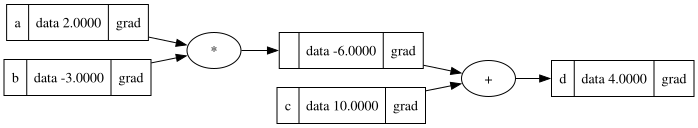

In [72]:
# this copy pastes from Karpathy's code - https://github.com/karpathy/micrograd/blob/c911406e5ace8742e5841a7e0df113ecb5d54685/trace_graph.ipynb#L10

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']

    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    nodes, edges = trace(root)
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad }" % (n.label, n.data), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

draw_dot(c)
draw_dot(d)

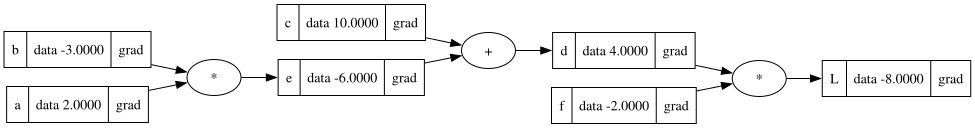

In [74]:
# complex version at 28:54 of video - https://www.youtube.com/watch?v=VMj-3S1tku0
a = Value(2.0); a.label='a'
b = Value(-3.0); b.label='b'
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f ; L.label = 'L'
draw_dot(L)